# FlyWire vs MCNS optic lobes co-clustering 

In this example, we will run a large co-cluster over the optic lobes for the FlyWire and the male CNS dataset. 

### Requirements:

Because we will be running a clustering over ~169k neurons, it is highly recommended to use a static connectivity dump instead of dynamically querying the CAVE backend.

**For FlyWire**: Go to the [Downloads page](https://codex.flywire.ai/api/download?dataset=fafb) on codex.flywire.ai and download `connections_princeton_no_threshold.csv.gz` under "Connections unfiltered". Place that file somewhere on your computer, note the path and adjust the filepath where we read in the data accordingly.

**For male CNS**: Go to the [landing page](https://male-cns.janelia.org/), navigate to "Downloads" -> "Download raw data" -> "Connectivity" and download `connectome-weights-male-cns-v0.9-minconf-0.5.feather`. Place that file somewhere on your computer, note the path and adjust the filepath where we read in the data accordingly.

In [13]:
import cocoa as cc
import pandas as pd

In [ ]:
# Grab all annotations for FlyWire and male CNS
ann_fw = cc.FlyWire().get_annotations()
ann_mcns = cc.MaleCNS().get_annotations()

# Subset to optic lobe-intrinsic neurons
ol_fw = ann_fw[ann_fw.super_class == "optic"]
ol_mcns = ann_mcns[ann_mcns.superclass == "ol_intrinsic"]

print(f"Found {len(ol_fw):,} optic lobe-intrinsic neurons in FlyWire")
print(f"Found {len(ol_mcns):,} optic lobe-intrinsic neurons in MaleCNS")

Found 77,539 optic lobe-intrinsic neurons in FlyWire
Found 89,399 optic lobe-intrinsic neurons in MaleCNS


Next, we will load and process the connectivity data we downloaded before:

In [ ]:
# Load the connectivity data for FlyWire (adjust path as needed)
cn_fw = pd.read_csv("~/Downloads/connections_princeton_no_threshold.csv.gz")
cn_fw.head()

,pre_root_id,post_root_id,neuropil,syn_count,nt_type
0,720575940625363947,720575940623224444,ME_L,12,GABA
1,720575940613354467,720575940616690107,ME_L,1,ACH
2,720575940630432382,720575940618518557,ME_L,67,ACH
3,720575940627314521,720575940626337738,ME_L,10,GABA
4,720575940616775218,720575940632128018,ME_L,1,ACH


In [ ]:
# The edge list is broken down by neuropil regions. We need to aggregate over those to get the full connectivity.
cn_fw = (
    cn_fw.groupby(["pre_root_id", "post_root_id"])
    .agg({"syn_count": "sum"})
    .reset_index()
)
cn_fw.head()

,pre_root_id,post_root_id,syn_count
0,720575940596125868,720575940605825666,6
1,720575940596125868,720575940607033010,2
2,720575940596125868,720575940608552405,6
3,720575940596125868,720575940608661187,1
4,720575940596125868,720575940609975854,5


In [ ]:
# Load the connectivity data for Male CNS (adjust path as needed)
cn_mcns = pd.read_feather(
    "~/Downloads/connectome-weights-male-cns-v0.9-minconf-0.5.feather"
)
cn_mcns.head()

,body_pre,body_post,weight
0,10352,10351,2591
1,13612,16076,2385
2,10663,10051,2248
3,10289,10611,2230
4,10893,10066,1929


Define the two datasets:

In [26]:
fw = cc.FlyWire(label="FlyWire", cn_object=cn_fw).add_neurons(ol_fw.root_id)
mcns = cc.MaleCNS(label="MaleCNS", cn_object=cn_mcns).add_neurons(ol_mcns.bodyId)

fw

class FlyWire <label=FlyWire;neurons=77539>

Now we can throw these at a co-clustering. 

Note that we're not actually calculating the final distances here, just generating the combined connectivity vector.
This is because the pairwise distances for 160k neurons require a lot of memory. Instead, we will take the 
connectivity vector and use a UMAP projection to visualize the data.

In [27]:
cl = cc.Clustering(fw, mcns).compile(skip_distance=True)
cl

Compiling connectivity vector for "FlyWire" (FlyWire) [1/2]
Compiling connectivity vector for "MaleCNS" (MaleCNS) [2/2]
Building across-dataset mapping for FlyWire, MaleCNS... 
  Found 7,795 unique labels covering 276,209 neurons.
All Done.
Combining connectivity vectors...   Using 2,320 unique labels for clustering.


/Users/philipps/Github/cocoa/cocoa/cluster.py:416: PerformanceWarning: The following operation may generate 6245209129 cells in the resulting pandas object.
  sources = []
/Users/philipps/Github/cocoa/cocoa/cluster.py:416: PerformanceWarning: The following operation may generate 8131518008 cells in the resulting pandas object.
  sources = []


Caching male CNS `type` annotations from neuprint... Done.
Done.
Generated a 166,938 by 4,640 observation vector.
Using on average 80.7% of neurons' synapses.
Worst case is keeping 0.0% of its synapses.
Skipping distance calculation.
All done.


Clustering <datasets=2;neurons=166938>

In [28]:
# The connectivity vector is available as `cl.vect_`
cl.vect_.head()

downstream                                            \
                       CB0282 PS099 Tm36 Sm40 LT1a SLP075 CB1030 CB0492   
720575940596125868          0     0    0    0    0      0      0      0   
720575940597856265          0     0    5    0    0      0      0      0   
720575940597944841          0     0    1   16    0      0      0      0   
720575940598267657          0     0    1    0    0      0      0      0   
720575940599333574          0     0    0    0    0      0      0      0   

                                  ... upstream                            \
                   aMe17a2 CL175  ...    mALD2 DNg106 LTe75 CB0073 PS087   
720575940596125868       0     0  ...        0      0     0      0     0   
720575940597856265       2     0  ...        0      0     0      0     0   
720575940597944841       0     0  ...        0      0     0      0     0   
720575940598267657       0     0  ...        0      0     0      0     0   
720575940599333574       0     0  ...        0      0     0      0     0   

                                                             
                   LC14a2 Pm10 AOTU008 LHAV3o1 AN_IPS_GNG_5  
720575940596125868      0    0       0       0            0  
720575940597856265      1    1       0       0            0  
720575940597944841      0    0       0       0            0  
720575940598267657      0    2       0       0            0  
720575940599333574      0    0       0       0            0  

[5 rows x 4640 columns]

In [29]:
import umap

# Run the UMAP on the connectivity vector
reducer = umap.UMAP(n_neighbors=10, metric="cosine", random_state=42, n_jobs=1)
embedding = reducer.fit_transform(cl.vect_)

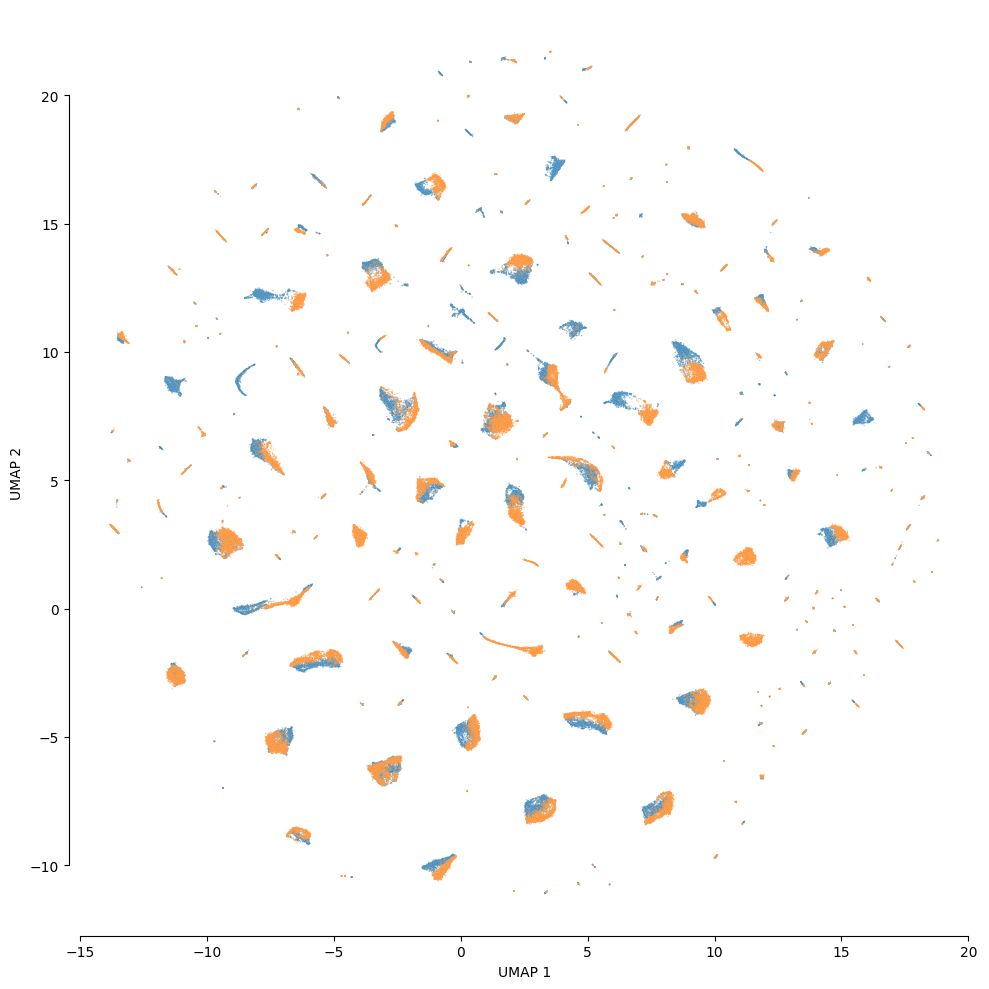

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    s=1,
    alpha=0.5,
    hue=cl.vect_sources_,  # color by dataset of origin
    palette="tab10",
    ax=ax,
)

# Avoid having a giant legend with all the different cell types
ax.get_legend().remove()

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")

sns.despine(trim=True)
plt.tight_layout()